# Smart Learning System
## Notebook 02: Data Preprocessing

### Objectives

This notebook prepares the datasets for machine-learning model development.

The preprocessing tasks include:

- Loading the raw datasets
- Standardising column names
- Removing duplicate records
- Validating numerical ranges
- Removing identifier columns from model features
- Transforming the raw mark-sheet dataset into a Commerce-domain prototype dataset
- Creating transparent academic-risk labels
- Cleaning the xAPI benchmark dataset
- Exporting processed datasets and preprocessing metadata

### Important Research Note

The raw mark-sheet dataset does not contain Sri Lankan GCE A/L Commerce subject
labels or an independently collected risk target.

For prototype development, the three numerical score variables are mapped to:

- Accounting
- Business Studies
- Economics

The original numerical values are preserved. Academic-risk labels are derived
using transparent performance and attendance thresholds. Therefore, this
processed dataset must be described as a rule-labelled Commerce-domain prototype
dataset rather than a genuine independently collected Commerce dataset.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    ML_ROOT = NOTEBOOK_DIR.parent
else:
    ML_ROOT = NOTEBOOK_DIR / "ml-model"

RAW_DATA_DIR = ML_ROOT / "datasets" / "raw"
PROCESSED_DATA_DIR = ML_ROOT / "datasets" / "processed"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("ML root:", ML_ROOT.resolve())
print("Raw datasets:", RAW_DATA_DIR.resolve())
print("Processed datasets:", PROCESSED_DATA_DIR.resolve())

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Raw datasets: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/raw
Processed datasets: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed


In [2]:
def load_dataset(file_name: str) -> pd.DataFrame:
    file_path = RAW_DATA_DIR / file_name

    if not file_path.exists():
        raise FileNotFoundError(
            f"Dataset was not found: {file_path.resolve()}"
        )

    dataframe = pd.read_csv(file_path)

    print(
        f"Loaded {file_name}: "
        f"{dataframe.shape[0]:,} rows × "
        f"{dataframe.shape[1]} columns"
    )

    return dataframe


pass_fail_raw = load_dataset("pass_fail_dataset.csv")
mark_sheet_raw = load_dataset("mark_sheet_clean_file1.csv")
xapi_raw = load_dataset("xAPI-Edu-Data.csv")

Loaded pass_fail_dataset.csv: 1,500 rows × 6 columns
Loaded mark_sheet_clean_file1.csv: 1,005 rows × 4 columns
Loaded xAPI-Edu-Data.csv: 480 rows × 17 columns


In [3]:
pass_fail_df = pass_fail_raw.copy()
commerce_df = mark_sheet_raw.copy()
xapi_df = xapi_raw.copy()

print("Working copies created successfully.")

Working copies created successfully.


In [4]:
def standardise_column_names(
    dataframe: pd.DataFrame
) -> pd.DataFrame:
    cleaned = dataframe.copy()

    cleaned.columns = (
        cleaned.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
    )

    return cleaned


def remove_duplicates(
    dataframe: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    duplicate_count = int(dataframe.duplicated().sum())

    cleaned = (
        dataframe
        .drop_duplicates()
        .reset_index(drop=True)
    )

    print(
        f"{dataset_name}: removed "
        f"{duplicate_count} duplicate rows."
    )

    return cleaned

In [5]:
print("Pass/Fail columns:")
print(pass_fail_df.columns.tolist())

display(pass_fail_df.head())

print("\nData types:")
display(pass_fail_df.dtypes.to_frame("data_type"))

Pass/Fail columns:
['student_id', 'attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week', 'pass']


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,59.7,66.5,73.4,6.4,1
1,2,74.3,54.7,18.3,1.2,0
2,3,81.8,98.9,70.7,11.1,1
3,4,89.4,85.3,74.2,5.6,1
4,5,60.5,21.9,37.3,7.5,0



Data types:


,data_type
student_id,int64
attendance_pct,float64
homework_pct,float64
midterm_score,float64
study_hours_per_week,float64
pass,int64


In [6]:
pass_fail_df = pass_fail_df.rename(
    columns={
        "midterm_score": "commerce_average_score"
    }
)

print(pass_fail_df.columns.tolist())

['student_id', 'attendance_pct', 'homework_pct', 'commerce_average_score', 'study_hours_per_week', 'pass']


In [7]:
pass_fail_df = pass_fail_df.rename(
    columns={
        "midterm_score": "commerce_average_score"
    }
)

print(pass_fail_df.columns.tolist())

['student_id', 'attendance_pct', 'homework_pct', 'commerce_average_score', 'study_hours_per_week', 'pass']


In [8]:
pass_fail_df = standardise_column_names(pass_fail_df)

pass_fail_df = remove_duplicates(
    pass_fail_df,
    "Pass/Fail dataset",
)

required_pass_fail_columns = [
    "student_id",
    "attendance_pct",
    "homework_pct",
    "commerce_average_score",
    "study_hours_per_week",
    "pass",
]
missing_columns = [
    column
    for column in required_pass_fail_columns
    if column not in pass_fail_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing Pass/Fail columns: {missing_columns}"
    )

print("Required columns verified.")

Pass/Fail dataset: removed 0 duplicate rows.
Required columns verified.


In [9]:
pass_fail_numeric_columns = [
    "student_id",
    "attendance_pct",
    "homework_pct",
    "commerce_average_score",
    "study_hours_per_week",
    "pass",
]

for column in pass_fail_numeric_columns:
    pass_fail_df[column] = pd.to_numeric(
        pass_fail_df[column],
        errors="coerce",
    )

missing_before = int(
    pass_fail_df.isna().sum().sum()
)

pass_fail_df = (
    pass_fail_df
    .dropna(subset=pass_fail_numeric_columns)
    .reset_index(drop=True)
)

print(
    "Invalid/missing values detected before removal:",
    missing_before,
)

print("Shape after numeric validation:", pass_fail_df.shape)

Invalid/missing values detected before removal: 0
Shape after numeric validation: (1500, 6)


In [10]:
percentage_columns = [
    "attendance_pct",
    "homework_pct",
    "commerce_average_score",
]

for column in percentage_columns:
    invalid_count = int(
        (
            (pass_fail_df[column] < 0)
            | (pass_fail_df[column] > 100)
        ).sum()
    )

    print(f"{column}: {invalid_count} invalid values")

    pass_fail_df[column] = (
        pass_fail_df[column]
        .clip(lower=0, upper=100)
    )

pass_fail_df["study_hours_per_week"] = (
    pass_fail_df["study_hours_per_week"]
    .clip(lower=0, upper=168)
)

valid_target_values = {0, 1}

invalid_target_count = int(
    (~pass_fail_df["pass"].isin(valid_target_values)).sum()
)

if invalid_target_count > 0:
    raise ValueError(
        f"Invalid Pass/Fail target values found: "
        f"{invalid_target_count}"
    )

pass_fail_df["pass"] = pass_fail_df["pass"].astype(int)

print("Pass/Fail ranges validated.")

attendance_pct: 0 invalid values
homework_pct: 0 invalid values
commerce_average_score: 0 invalid values
Pass/Fail ranges validated.


In [11]:
pass_fail_processed = pass_fail_df[
    [
        "student_id",
        "attendance_pct",
        "homework_pct",
        "commerce_average_score",
        "study_hours_per_week",
        "pass",
    ]
].copy()


print("Final Pass/Fail shape:", pass_fail_processed.shape)

display(pass_fail_processed.head())

print("\nTarget distribution:")
display(
    pass_fail_processed["pass"]
    .value_counts()
    .rename_axis("pass")
    .to_frame("count")
)

Final Pass/Fail shape: (1500, 6)


,student_id,attendance_pct,homework_pct,commerce_average_score,study_hours_per_week,pass
0,1,59.7,66.5,73.4,6.4,1
1,2,74.3,54.7,18.3,1.2,0
2,3,81.8,98.9,70.7,11.1,1
3,4,89.4,85.3,74.2,5.6,1
4,5,60.5,21.9,37.3,7.5,0



Target distribution:


,count
pass,
1,883
0,617


In [12]:
pass_fail_output_path = (
    PROCESSED_DATA_DIR
    / "pass_fail_processed.csv"
)

pass_fail_processed.to_csv(
    pass_fail_output_path,
    index=False,
)

print("Saved:", pass_fail_output_path.resolve())

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/pass_fail_processed.csv


In [13]:
print("Original mark-sheet columns:")
print(commerce_df.columns.tolist())

display(commerce_df.head())

print("\nOriginal shape:", commerce_df.shape)
print(
    "Original duplicates:",
    commerce_df.duplicated().sum(),
)

Original mark-sheet columns:
['Math_Score', 'English_Score', 'Science_Score', 'Attendance']


,Math_Score,English_Score,Science_Score,Attendance
0,79.967142,86.792265,72.598574,75.460962
1,73.617357,81.095604,76.843851,80.698075
2,81.476885,70.715564,71.660641,82.931972
3,90.230299,62.236759,75.536308,94.438438
4,72.658466,78.378680,62.851083,87.782766



Original shape: (1005, 4)
Original duplicates: 3


In [14]:
required_mark_sheet_columns = [
    "Math_Score",
    "English_Score",
    "Science_Score",
    "Attendance",
]

missing_columns = [
    column
    for column in required_mark_sheet_columns
    if column not in commerce_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing mark-sheet columns: {missing_columns}"
    )

print("Raw mark-sheet columns verified.")

Raw mark-sheet columns verified.


In [15]:
commerce_df = commerce_df.rename(
    columns={
        "Math_Score": "Accounting_Score",
        "English_Score": "Business_Studies_Score",
        "Science_Score": "Economics_Score",
        "Attendance": "Attendance_Percentage",
    }
)

print("Commerce-domain columns:")
print(commerce_df.columns.tolist())

display(commerce_df.head())

Commerce-domain columns:
['Accounting_Score', 'Business_Studies_Score', 'Economics_Score', 'Attendance_Percentage']


,Accounting_Score,Business_Studies_Score,Economics_Score,Attendance_Percentage
0,79.967142,86.792265,72.598574,75.460962
1,73.617357,81.095604,76.843851,80.698075
2,81.476885,70.715564,71.660641,82.931972
3,90.230299,62.236759,75.536308,94.438438
4,72.658466,78.378680,62.851083,87.782766


In [16]:
commerce_df = remove_duplicates(
    commerce_df,
    "Commerce risk dataset",
)

print("Shape after duplicate removal:", commerce_df.shape)

Commerce risk dataset: removed 3 duplicate rows.
Shape after duplicate removal: (1002, 4)


In [17]:
commerce_numeric_columns = [
    "Accounting_Score",
    "Business_Studies_Score",
    "Economics_Score",
    "Attendance_Percentage",
]

for column in commerce_numeric_columns:
    commerce_df[column] = pd.to_numeric(
        commerce_df[column],
        errors="coerce",
    )

missing_by_column = (
    commerce_df[commerce_numeric_columns]
    .isna()
    .sum()
)

display(
    missing_by_column
    .rename("missing_count")
    .to_frame()
)

commerce_df = (
    commerce_df
    .dropna(subset=commerce_numeric_columns)
    .reset_index(drop=True)
)

print("Shape after missing-value handling:", commerce_df.shape)

,missing_count
Accounting_Score,0
Business_Studies_Score,0
Economics_Score,0
Attendance_Percentage,0


Shape after missing-value handling: (1002, 4)


In [18]:
range_validation_rows = []

for column in commerce_numeric_columns:
    below_zero = int((commerce_df[column] < 0).sum())
    above_hundred = int((commerce_df[column] > 100).sum())

    range_validation_rows.append({
        "column": column,
        "below_zero": below_zero,
        "above_hundred": above_hundred,
    })

    commerce_df[column] = (
        commerce_df[column]
        .clip(lower=0, upper=100)
    )

range_validation = pd.DataFrame(
    range_validation_rows
)

display(range_validation)

print("All values clipped to the valid 0–100 range.")

,column,below_zero,above_hundred
0,Accounting_Score,0,8
1,Business_Studies_Score,0,8
2,Economics_Score,0,6
3,Attendance_Percentage,0,2


All values clipped to the valid 0–100 range.


In [19]:
commerce_df.insert(
    0,
    "student_id",
    [
        f"COM{index:04d}"
        for index in range(
            1,
            len(commerce_df) + 1,
        )
    ],
)

display(commerce_df.head())

,student_id,Accounting_Score,Business_Studies_Score,Economics_Score,Attendance_Percentage
0,COM0001,79.967142,86.792265,72.598574,75.460962
1,COM0002,73.617357,81.095604,76.843851,80.698075
2,COM0003,81.476885,70.715564,71.660641,82.931972
3,COM0004,90.230299,62.236759,75.536308,94.438438
4,COM0005,72.658466,78.378680,62.851083,87.782766


In [20]:
commerce_subject_columns = [
    "Accounting_Score",
    "Business_Studies_Score",
    "Economics_Score",
]

commerce_df["Subject_Average"] = (
    commerce_df[commerce_subject_columns]
    .mean(axis=1)
    .round(2)
)

display(
    commerce_df[
        commerce_subject_columns
        + ["Subject_Average"]
    ].head()
)

,Accounting_Score,Business_Studies_Score,Economics_Score,Subject_Average
0,79.967142,86.792265,72.598574,79.79
1,73.617357,81.095604,76.843851,77.19
2,81.476885,70.715564,71.660641,74.62
3,90.230299,62.236759,75.536308,76.00
4,72.658466,78.378680,62.851083,71.30


In [21]:
def assign_academic_risk(
    subject_average: float,
    attendance_percentage: float,
) -> str:
    if (
        subject_average < 35
        or attendance_percentage < 60
    ):
        return "High Risk"

    if (
        subject_average < 55
        or attendance_percentage < 75
    ):
        return "Medium Risk"

    return "Low Risk"


commerce_df["risk_level"] = [
    assign_academic_risk(
        subject_average=row.Subject_Average,
        attendance_percentage=row.Attendance_Percentage,
    )
    for row in commerce_df.itertuples()
]

display(
    commerce_df[
        [
            "student_id",
            "Subject_Average",
            "Attendance_Percentage",
            "risk_level",
        ]
    ].head(10)
)

,student_id,Subject_Average,Attendance_Percentage,risk_level
0,COM0001,79.79,75.460962,Low Risk
1,COM0002,77.19,80.698075,Low Risk
2,COM0003,74.62,82.931972,Low Risk
3,COM0004,76.00,94.438438,Low Risk
4,COM0005,71.30,87.782766,Low Risk
5,COM0006,76.56,78.322592,Low Risk
6,COM0007,83.18,87.430181,Low Risk
7,COM0008,77.25,77.263480,Low Risk
8,COM0009,78.72,90.413455,Low Risk
9,COM0010,76.50,82.644377,Low Risk


In [22]:
risk_order = [
    "Low Risk",
    "Medium Risk",
    "High Risk",
]

risk_counts = (
    commerce_df["risk_level"]
    .value_counts()
    .reindex(risk_order, fill_value=0)
)

risk_percentages = (
    risk_counts / risk_counts.sum() * 100
).round(2)

risk_distribution = pd.DataFrame({
    "count": risk_counts,
    "percentage": risk_percentages,
})

display(risk_distribution)

,count,percentage
risk_level,,
Low Risk,974,97.21
Medium Risk,28,2.79
High Risk,0,0.00


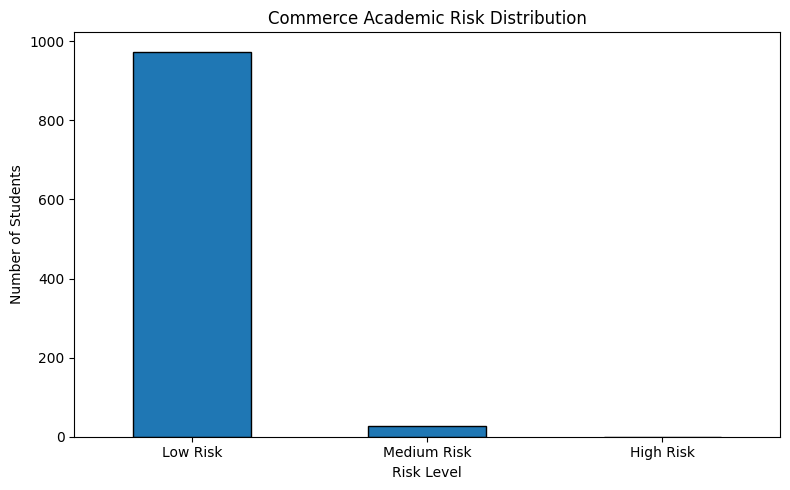

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_distribution.png


In [23]:
plt.figure(figsize=(8, 5))

risk_counts.plot(
    kind="bar",
    edgecolor="black",
)

plt.title("Commerce Academic Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()

commerce_risk_figure_path = (
    FIGURES_DIR
    / "commerce_risk_distribution.png"
)

plt.savefig(
    commerce_risk_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    commerce_risk_figure_path.resolve(),
)

In [24]:
commerce_risk_processed = commerce_df[
    [
        "student_id",
        "Accounting_Score",
        "Business_Studies_Score",
        "Economics_Score",
        "Attendance_Percentage",
        "Subject_Average",
        "risk_level",
    ]
].copy()

print(
    "Final Commerce dataset shape:",
    commerce_risk_processed.shape,
)

display(commerce_risk_processed.head(10))

Final Commerce dataset shape: (1002, 7)


,student_id,Accounting_Score,Business_Studies_Score,Economics_Score,Attendance_Percentage,Subject_Average,risk_level
0,COM0001,79.967142,86.792265,72.598574,75.460962,79.79,Low Risk
1,COM0002,73.617357,81.095604,76.843851,80.698075,77.19,Low Risk
2,COM0003,81.476885,70.715564,71.660641,82.931972,74.62,Low Risk
3,COM0004,90.230299,62.236759,75.536308,94.438438,76.00,Low Risk
4,COM0005,72.658466,78.378680,62.851083,87.782766,71.30,Low Risk
5,COM0006,75.264884,74.721825,79.706350,78.322592,76.56,Low Risk
6,COM0007,90.792128,80.742319,78.009644,87.430181,83.18,Low Risk
7,COM0008,82.674347,77.622062,71.463291,77.263480,77.25,Low Risk
8,COM0009,70.305256,82.594633,83.273965,90.413455,78.72,Low Risk
9,COM0010,80.425600,63.577177,85.500561,82.644377,76.50,Low Risk


In [25]:
commerce_output_path = (
    PROCESSED_DATA_DIR
    / "commerce_risk_dataset.csv"
)

commerce_risk_processed.to_csv(
    commerce_output_path,
    index=False,
)

print("Saved:", commerce_output_path.resolve())

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/commerce_risk_dataset.csv


In [26]:
print("xAPI shape:", xapi_df.shape)
print("xAPI columns:")
print(xapi_df.columns.tolist())

display(xapi_df.head())

xAPI shape: (480, 17)
xAPI columns:
['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [27]:
xapi_df = standardise_column_names(xapi_df)

xapi_df = remove_duplicates(
    xapi_df,
    "xAPI dataset",
)

print("xAPI shape after duplicate removal:", xapi_df.shape)

xAPI dataset: removed 2 duplicate rows.
xAPI shape after duplicate removal: (478, 17)


In [28]:
xapi_df = xapi_df.rename(
    columns={
        "NationalITy": "Nationality",
        "PlaceofBirth": "Place_of_Birth",
        "StageID": "Stage_ID",
        "GradeID": "Grade_ID",
        "SectionID": "Section_ID",
        "VisITedResources": "Visited_Resources",
        "AnnouncementsView": "Announcements_View",
        "ParentAnsweringSurvey": "Parent_Answering_Survey",
        "ParentschoolSatisfaction": "Parent_School_Satisfaction",
        "StudentAbsenceDays": "Student_Absence_Days",
    }
)

print(xapi_df.columns.tolist())

['gender', 'Nationality', 'Place_of_Birth', 'Stage_ID', 'Grade_ID', 'Section_ID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'Visited_Resources', 'Announcements_View', 'Discussion', 'Parent_Answering_Survey', 'Parent_School_Satisfaction', 'Student_Absence_Days', 'Class']


In [29]:
print(
    "Total xAPI missing values:",
    int(xapi_df.isna().sum().sum()),
)

categorical_columns = (
    xapi_df
    .select_dtypes(include=["object", "string"])
    .columns
)

for column in categorical_columns:
    xapi_df[column] = (
        xapi_df[column]
        .astype(str)
        .str.strip()
    )

display(
    xapi_df[categorical_columns]
    .head()
)

Total xAPI missing values: 0


,gender,Nationality,Place_of_Birth,Stage_ID,Grade_ID,Section_ID,Topic,Semester,Relation,Parent_Answering_Survey,Parent_School_Satisfaction,Student_Absence_Days,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,No,Bad,Above-7,M


In [30]:
xapi_numeric_columns = [
    "raisedhands",
    "Visited_Resources",
    "Announcements_View",
    "Discussion",
]

for column in xapi_numeric_columns:
    xapi_df[column] = pd.to_numeric(
        xapi_df[column],
        errors="coerce",
    )

    xapi_df[column] = (
        xapi_df[column]
        .clip(lower=0, upper=100)
    )

xapi_df = (
    xapi_df
    .dropna(subset=xapi_numeric_columns + ["Class"])
    .reset_index(drop=True)
)

print("Final xAPI shape:", xapi_df.shape)

Final xAPI shape: (478, 17)


In [31]:
valid_xapi_classes = {"L", "M", "H"}

observed_classes = set(
    xapi_df["Class"].unique()
)

invalid_classes = (
    observed_classes - valid_xapi_classes
)

if invalid_classes:
    raise ValueError(
        f"Invalid xAPI classes found: {invalid_classes}"
    )

display(
    xapi_df["Class"]
    .value_counts()
    .rename_axis("Class")
    .to_frame("count")
)

,count
Class,
M,211
H,142
L,125


In [32]:
xapi_output_path = (
    PROCESSED_DATA_DIR
    / "xapi_processed.csv"
)

xapi_df.to_csv(
    xapi_output_path,
    index=False,
)

print("Saved:", xapi_output_path.resolve())

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/xapi_processed.csv


In [33]:
preprocessing_metadata = {
    "pass_fail_model": {
        "dataset": "pass_fail_processed.csv",
        "identifier_column": "student_id",
        "feature_columns": [
            "attendance_pct",
            "homework_pct",
            "commerce_average_score",
            "study_hours_per_week",
        ],
        "target_column": "pass",
        "task": "binary_classification",
    },
    "commerce_risk_model": {
        "dataset": "commerce_risk_dataset.csv",
        "identifier_column": "student_id",
        "feature_columns": [
            "Accounting_Score",
            "Business_Studies_Score",
            "Economics_Score",
            "Attendance_Percentage",
        ],
        "excluded_derived_column": "Subject_Average",
        "target_column": "risk_level",
        "task": "multiclass_classification",
        "label_source": "rule_derived",
    },
    "xapi_benchmark_model": {
        "dataset": "xapi_processed.csv",
        "target_column": "Class",
        "task": "multiclass_classification",
        "role": "external_benchmark",
    },
}

metadata_path = (
    REPORTS_DIR
    / "preprocessing_metadata.json"
)

metadata_path.write_text(
    json.dumps(
        preprocessing_metadata,
        indent=2,
    ),
    encoding="utf-8",
)

print("Saved:", metadata_path.resolve())

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/preprocessing_metadata.json


In [34]:
processed_quality_summary = pd.DataFrame({
    "dataset": [
        "Pass/Fail Processed",
        "Commerce Risk Processed",
        "xAPI Processed",
    ],
    "rows": [
        pass_fail_processed.shape[0],
        commerce_risk_processed.shape[0],
        xapi_df.shape[0],
    ],
    "columns": [
        pass_fail_processed.shape[1],
        commerce_risk_processed.shape[1],
        xapi_df.shape[1],
    ],
    "missing_values": [
        int(pass_fail_processed.isna().sum().sum()),
        int(commerce_risk_processed.isna().sum().sum()),
        int(xapi_df.isna().sum().sum()),
    ],
    "duplicate_rows": [
        int(pass_fail_processed.duplicated().sum()),
        int(commerce_risk_processed.duplicated().sum()),
        int(xapi_df.duplicated().sum()),
    ],
})

display(processed_quality_summary)

quality_summary_path = (
    REPORTS_DIR
    / "processed_data_quality_summary.csv"
)

processed_quality_summary.to_csv(
    quality_summary_path,
    index=False,
)

print("Saved:", quality_summary_path.resolve())

,dataset,rows,columns,missing_values,duplicate_rows
0,Pass/Fail Processed,1500,6,0,0
1,Commerce Risk Processed,1002,7,0,0
2,xAPI Processed,478,17,0,0


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/processed_data_quality_summary.csv


In [35]:
expected_output_files = [
    PROCESSED_DATA_DIR / "pass_fail_processed.csv",
    PROCESSED_DATA_DIR / "commerce_risk_dataset.csv",
    PROCESSED_DATA_DIR / "xapi_processed.csv",
    REPORTS_DIR / "preprocessing_metadata.json",
    REPORTS_DIR / "processed_data_quality_summary.csv",
]

print("Generated outputs:")

for file_path in expected_output_files:
    status = "FOUND" if file_path.exists() else "MISSING"
    print(f"[{status}] {file_path.resolve()}")

Generated outputs:
[FOUND] /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/pass_fail_processed.csv
[FOUND] /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/commerce_risk_dataset.csv
[FOUND] /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/xapi_processed.csv
[FOUND] /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/preprocessing_metadata.json
[FOUND] /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/processed_data_quality_summary.csv


## Preprocessing Summary

### Pass/Fail Dataset

The Pass/Fail dataset was validated, converted to numerical form, and checked
for invalid ranges and target values. The student identifier was retained for
record traceability but will be excluded from model training.

### Commerce Academic-Risk Dataset

The original numerical mark-sheet dataset was preserved in the raw data
directory. During preprocessing, its three numerical score variables were
mapped to Accounting, Business Studies, and Economics to align the prototype
with the Sri Lankan GCE A/L Commerce domain.

Duplicate rows were removed, numerical ranges were validated, student
identifiers were generated, and a subject average was calculated.

The academic-risk target was derived using transparent performance and
attendance thresholds:

- High Risk: subject average below 35 or attendance below 60%
- Medium Risk: subject average below 55 or attendance below 75%
- Low Risk: subject average of at least 55 and attendance of at least 75%

The subject-average field will not be used as a model feature because it was
used directly to derive the target labels.

### xAPI Benchmark Dataset

Duplicate records were removed, column names were standardised, categorical
values were cleaned, and numerical engagement variables were validated. The
dataset will be used only as an external benchmark because its context differs
from the Sri Lankan GCE A/L Commerce environment.

### Generated Files

- `pass_fail_processed.csv`
- `commerce_risk_dataset.csv`
- `xapi_processed.csv`
- `preprocessing_metadata.json`
- `processed_data_quality_summary.csv`

### Next Step

Notebook 03A will compare supervised machine-learning algorithms for the
Pass/Fail prediction task.